In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("AirPassengers.csv")
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

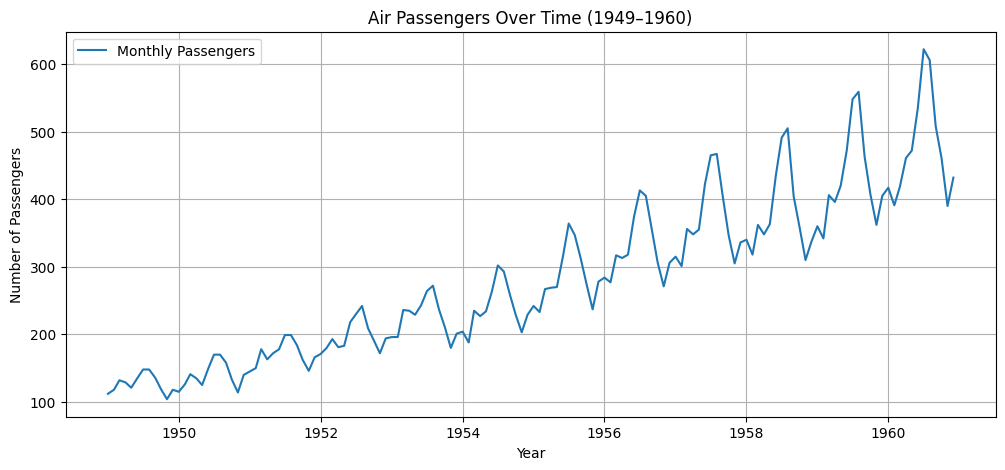

In [3]:
# Plot original data

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Passengers'], label="Monthly Passengers")
plt.title("Air Passengers Over Time (1949–1960)")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.grid(True)
plt.legend()
plt.show()

In [4]:
# Preprocess the Data

import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[['Passengers']])

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(data_scaled, window_size)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [5]:
# Build and Train the LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=100, verbose=1)

Epoch 1/100


c:\Users\RISHIL T K\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2105
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1779
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1293
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1070
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0820
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0724
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0345
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0170
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0181
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0126
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0112
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0107
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0118
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0105
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0096
Epoch 16/100
5/5 ━━━━━━━━━━━━━━

In [6]:
# Forecast Future Months

future_months = 12  # Change this to predict more or fewer months
input_seq = data_scaled[-window_size:].reshape(1, window_size, 1)

future_preds = []
for _ in range(future_months):
    pred = model.predict(input_seq, verbose=0)
    future_preds.append(pred[0][0])
    input_seq = np.append(input_seq[:, 1:, :], [[[pred[0][0]]]], axis=1)

predicted_values = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=future_months, freq='MS')

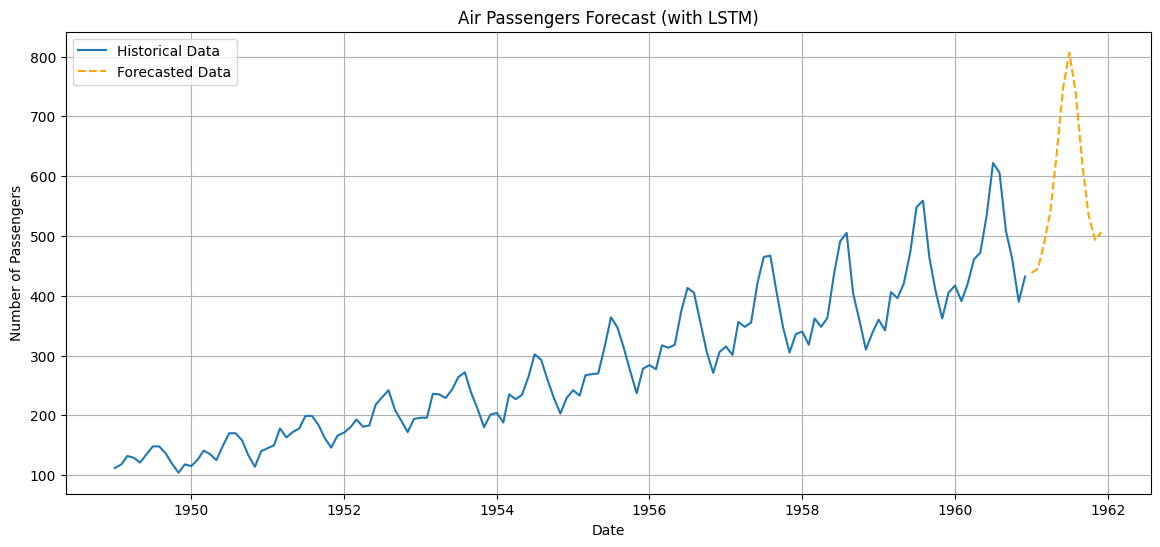

In [7]:
# Plot Predictions

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Passengers'], label='Historical Data')
plt.plot(future_dates, predicted_values, label='Forecasted Data', linestyle='--', color='orange')
plt.title('Air Passengers Forecast (with LSTM)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()